In [1]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

c:\Users\cjc72\Desktop\e-commerce-ai-ml-retention-platform\e-commerce-ai-ml-retention-platform\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Model Import

In [2]:
# Load the final model
import joblib

model_pipeline = joblib.load(
    "../models/churn_model.pkl"
)
model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['frequency','monetary','avg_order_value',...,'state','latitude', 'longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

### Data Import

In [3]:
PROJECT_ROOT = Path("../")

DATA_PATH = (
    PROJECT_ROOT /
    "data" /
    "features" /
    "customer_churn_dataset.csv"
)


customers_ml = pd.read_csv(DATA_PATH)

customers_ml.head()

,frequency,monetary,avg_order_value,unique_categories,unique_sellers,avg_review_score,late_delivery_ratio,avg_installments,max_installments,payment_method_count,preferred_payment_type,state,latitude,longitude,churn_label
0,2,82.82,41.41,2,2,4.5,0.0,1.0,1.0,1,credit_card,SP,-23.577482,-46.587077,1
1,1,141.46,141.46,1,1,4.0,0.0,1.0,1.0,1,boleto,BA,-12.186877,-44.540232,0
2,1,179.12,179.12,1,1,5.0,0.0,3.0,3.0,1,credit_card,GO,-16.745150,-48.514783,0
3,1,72.20,72.20,1,1,5.0,0.0,1.0,1.0,1,credit_card,RN,-5.774002,-35.270976,1
4,1,28.62,28.62,1,1,5.0,0.0,1.0,1.0,1,credit_card,SP,-23.676257,-46.514580,1


In [4]:
customers_ml.shape

(96096, 15)

### Train Test Split

In [5]:
X = customers_ml.drop(columns=["churn_label"])

y = customers_ml["churn_label"]

In [6]:
X.value_counts()

frequency  monetary  avg_order_value  unique_categories  unique_sellers  avg_review_score  late_delivery_ratio  avg_installments  max_installments  payment_method_count  preferred_payment_type  state  latitude    longitude 
1          82.98     82.980000        1                  1               5.000000          0.000000             1.000000          1.0               1                     credit_card             SP     -23.604706  -46.693332    3
           42.27     42.270000        1                  1               5.000000          0.000000             1.000000          1.0               1                     credit_card             RN     -5.887088   -35.207494    3
           65.00     65.000000        1                  1               5.000000          0.000000             1.000000          1.0               1                     credit_card             PR     -25.434017  -49.297219    2
           0.00      0.000000         0                  0               1.000000        

In [7]:
y.value_counts()

churn_label
1    64212
0    31884
Name: count, dtype: int64

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (76876, 14)
Test set shape: (19220, 14)


### Create Shared Preprocessing Components
- Uses **SimpleImputer** library

In [10]:
print("Categorical features:")
categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()
print(categorical_features)

print("\nNumerical features:")
numeric_features = X.select_dtypes(
    exclude="object"
).columns.tolist()
print(numeric_features)




Categorical features:
['preferred_payment_type', 'state']

Numerical features:
['frequency', 'monetary', 'avg_order_value', 'unique_categories', 'unique_sellers', 'avg_review_score', 'late_delivery_ratio', 'avg_installments', 'max_installments', 'payment_method_count', 'latitude', 'longitude']


#### Numerical Imputation

In [11]:
# Missing value imputation for numerical features
numeric_imputer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"  # Use median
            )
        )
    ]
)

#### Categorical One-Hot Encoding

In [12]:
# Missing value imputation for categorical features
categorical_encoder = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"   # Use mode
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"   # Ignore unknown categories during transformation when deployment
            )
        )
    ]
)

In [13]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_imputer,
            numeric_features
        ),
        (
            "categorical",
            categorical_encoder,
            categorical_features
        )
    ],
    remainder="drop"
)

In [14]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (76876, 46)
Processed testing shape: (19220, 46)


### SHAP Explainer for model interpretation

In [15]:
model_pipeline.fit(X_train, y_train)
model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['frequency','monetary','avg_order_value',...,'state','latitude', 'longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

In [16]:
test_predictions = model_pipeline.predict(X_test)
test_probabilities = model_pipeline.predict_proba(X_test)[:, 1]

print("Predictions:", test_predictions[:10])
print("Probabilities:", test_probabilities[:10])

Predictions: [1 0 0 0 1 0 1 1 0 0]
Probabilities: [0.55002572 0.38223458 0.23364224 0.38592101 0.61208026 0.21015791
 0.64365959 0.62378247 0.4544354  0.38944844]


In [17]:
# Extract the trained preprocessing component
X_test_processed = model_pipeline.named_steps["preprocessor"].transform(X_test)

# Get feature names
feature_names = model_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

In [18]:
X_test_processed_df = pd.DataFrame(
    X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed,
    columns=feature_names,
    index=X_test.index
)

In [19]:
print("Original features:", X_test.shape[1])
print("Processed features:", X_test_processed_df.shape[1])

display(X_test_processed_df.head())

Original features: 14
Processed features: 46


,numeric__frequency,numeric__monetary,numeric__avg_order_value,numeric__unique_categories,numeric__unique_sellers,numeric__avg_review_score,numeric__late_delivery_ratio,numeric__avg_installments,numeric__max_installments,numeric__payment_method_count,...,categorical__state_RJ,categorical__state_RN,categorical__state_RO,categorical__state_RR,categorical__state_RS,categorical__state_SC,categorical__state_SE,categorical__state_SP,categorical__state_TO,categorical__state_unknown
27388,1.0,74.57,74.57,1.0,1.0,5.0,0.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32587,1.0,157.20,157.20,1.0,1.0,5.0,0.0,3.0,3.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43312,1.0,52.76,26.38,1.0,1.0,4.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
22728,1.0,98.55,98.55,1.0,1.0,3.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59344,1.0,71.43,71.43,1.0,1.0,5.0,0.0,3.0,3.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
model = model_pipeline.named_steps["model"]
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balance

In [ ]:
# Extract the trained model
model = model_pipeline.named_steps["model"]

# Create explainer for the model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_processed)

In [ ]:
print("X_test shape:", X_test_processed.shape)
print("SHAP shape:", shap_values.shape)

X_test shape: (19220, 47)
SHAP shape: (19220, 47)


### Global Feature Importance

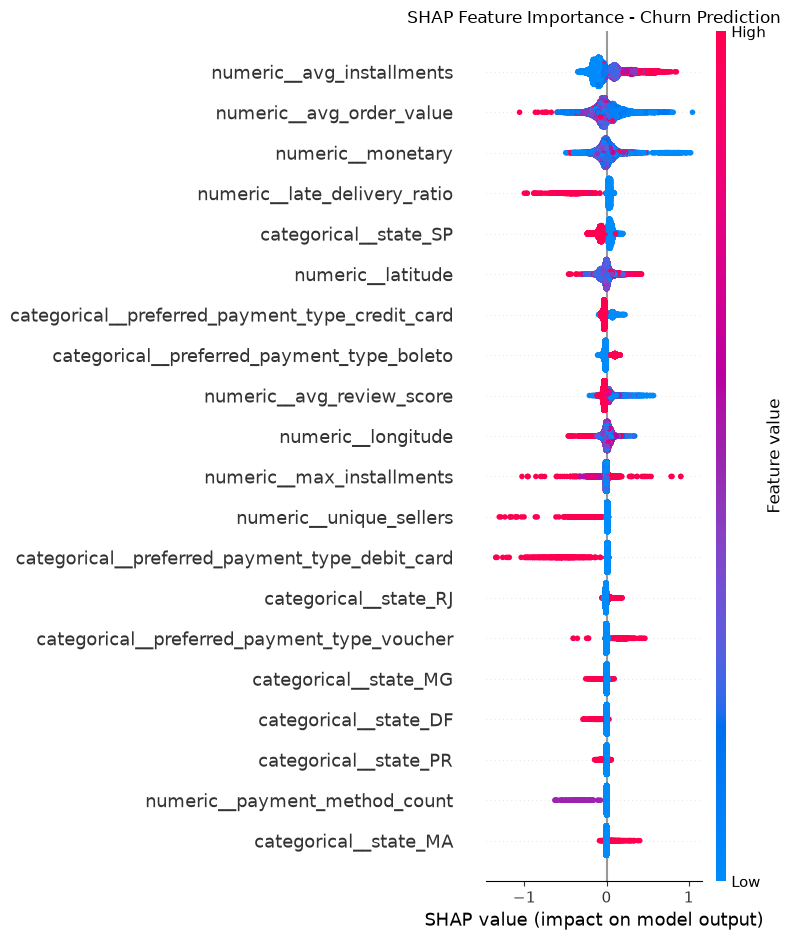

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Feature Importance - Churn Prediction")
plt.tight_layout()
plt.show()

### Mean Absolute SHAP Importance

In [ ]:
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

shap_importance

,feature,mean_abs_shap
0,numeric__avg_installments,0.147542
1,numeric__avg_order_value,0.107082
2,numeric__monetary,0.074820
3,numeric__late_delivery_ratio,0.067502
4,categorical__state_SP,0.057046
5,numeric__latitude,0.049413
6,categorical__preferred_payment_type_credit_card,0.039435
7,categorical__preferred_payment_type_boleto,0.037072
8,numeric__avg_review_score,0.034984
9,numeric__longitude,0.032577


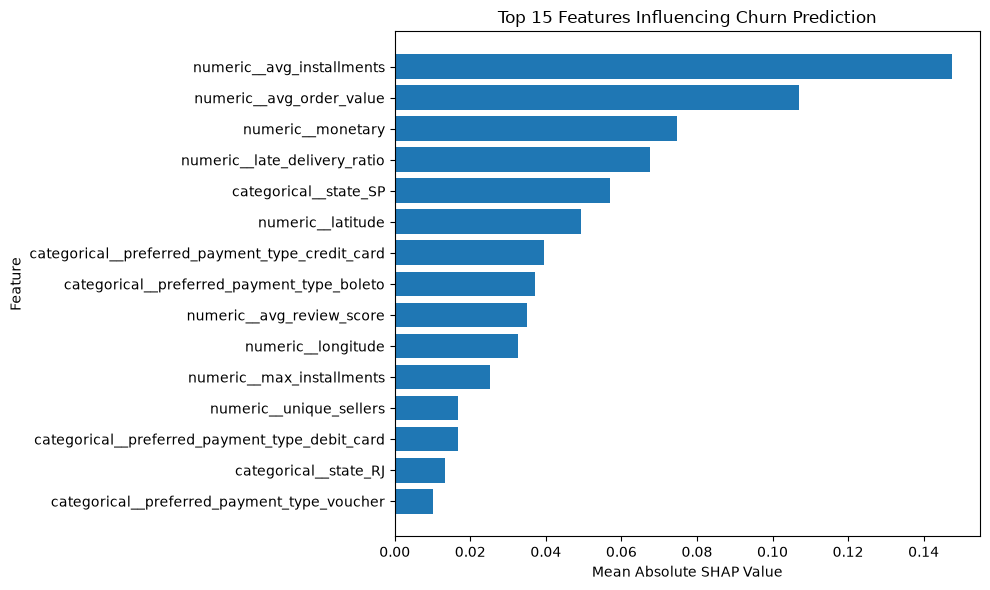

In [ ]:
top_features = shap_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["mean_abs_shap"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Churn Prediction")
plt.tight_layout()
plt.show()

### Individual Customer Explanation

In [ ]:
# Select the customer by position
customer_position = 0

customer_features = pd.DataFrame(
    X_test_processed[customer_position:customer_position + 1],
    columns=feature_names
)

customer_features

,numeric__frequency,numeric__monetary,numeric__avg_order_value,numeric__frequency.1,numeric__unique_categories,numeric__unique_sellers,numeric__avg_review_score,numeric__late_delivery_ratio,numeric__avg_installments,numeric__max_installments,...,categorical__state_RJ,categorical__state_RN,categorical__state_RO,categorical__state_RR,categorical__state_RS,categorical__state_SC,categorical__state_SE,categorical__state_SP,categorical__state_TO,categorical__state_unknown
0,1.0,135.0,135.0,1.0,1.0,1.0,4.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
# Original customer features for model prediction
customer_features = X_test.iloc[[customer_position]]

# Predict churn probability
customer_probability = model_pipeline.predict_proba(
    customer_features
)[0, 1]

print(
    f"Churn probability: {customer_probability:.2%}"
)


Churn probability: 51.36%


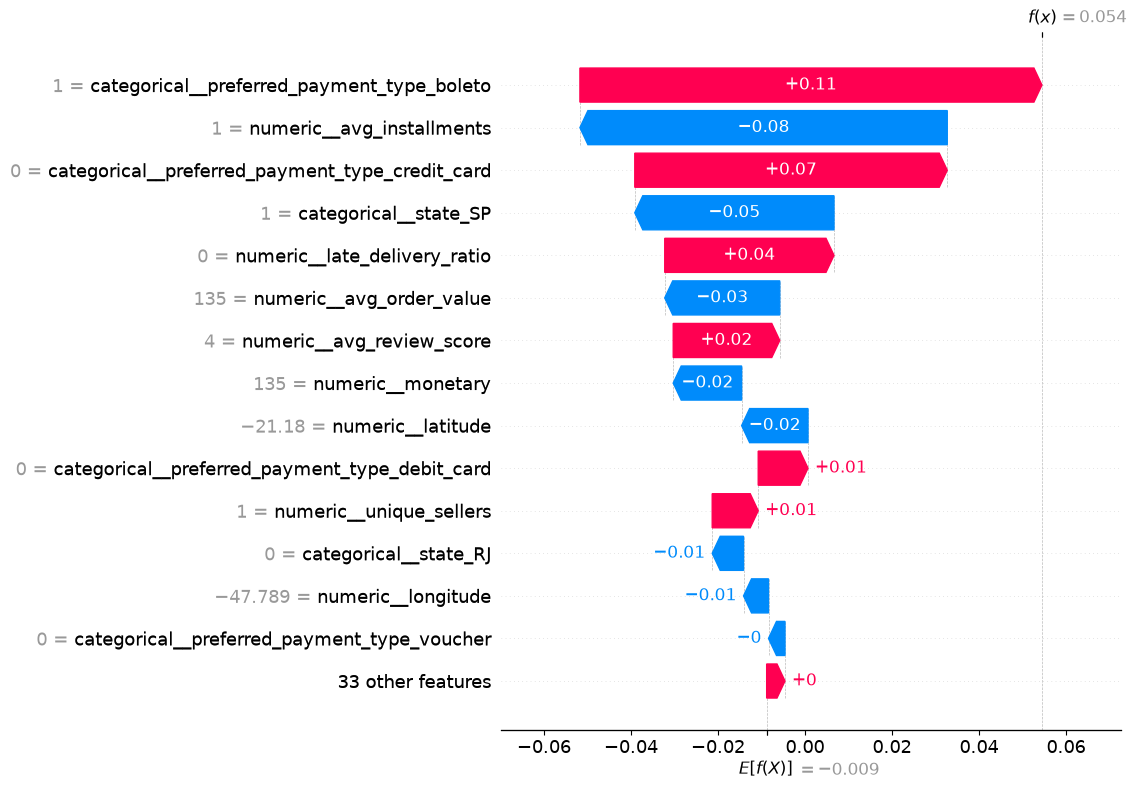

In [ ]:
# Get SHAP values for the same customer
customer_shap_values = shap_values[
    customer_position
]

# Get the processed features for the selected customer
customer_processed = X_test_processed[
    customer_position:customer_position + 1
]

# Convert to DataFrame so SHAP can display feature names
customer_processed_df = pd.DataFrame(
    customer_processed.toarray()
    if hasattr(customer_processed, "toarray")
    else customer_processed,
    columns=feature_names,
    index=X_test.index[customer_position:customer_position + 1]
)


# Get SHAP values for the same customer
customer_shap_values = shap_values[
    customer_position
]

# Create SHAP Explanation
customer_explanation = shap.Explanation(
    values=customer_shap_values,
    base_values=explainer.expected_value,
    data=customer_processed_df.iloc[0].values,
    feature_names=feature_names
)

# Plot waterfall
shap.waterfall_plot(
    customer_explanation,
    max_display=15
)

### Create a Human-Readable Explanation (For LLM Layer)

In [ ]:
customer_explanation = pd.DataFrame({
    "feature": customer_processed_df.columns,
    "feature_value": customer_processed_df.iloc[0].values,
    "shap_value": customer_shap_values
})

# Absolute SHAP value for measuring contribution strength
customer_explanation["abs_shap"] = (
    customer_explanation["shap_value"].abs()
)

In [ ]:
# Top 5 features contributing to churn prediction for the selected customer
top_customer_factors = (
    customer_explanation
    .sort_values("abs_shap", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

top_customer_factors

,feature,feature_value,shap_value,abs_shap
0,categorical__preferred_payment_type_boleto,1.0,0.106186,0.106186
1,numeric__avg_installments,1.0,-0.084428,0.084428
2,categorical__preferred_payment_type_credit_card,0.0,0.071820,0.071820
3,categorical__state_SP,1.0,-0.045787,0.045787
4,numeric__late_delivery_ratio,0.0,0.038902,0.038902


In [ ]:
# Factors pushing toward churn
risk_factors = (
    customer_explanation[
        customer_explanation["shap_value"] > 0
    ]
    .sort_values("shap_value", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

risk_factors

,feature,feature_value,shap_value,abs_shap
0,categorical__preferred_payment_type_boleto,1.0,0.106186,0.106186
1,categorical__preferred_payment_type_credit_card,0.0,0.071820,0.071820
2,numeric__late_delivery_ratio,0.0,0.038902,0.038902
3,numeric__avg_review_score,4.0,0.024487,0.024487
4,categorical__preferred_payment_type_debit_card,0.0,0.011441,0.011441


In [ ]:
# Factors pushing away from churn
protective_factors = (
    customer_explanation[
        customer_explanation["shap_value"] < 0
    ]
    .sort_values("shap_value", ascending=True)
    .head(5)
    .reset_index(drop=True)
)

protective_factors

,feature,feature_value,shap_value,abs_shap
0,numeric__avg_installments,1.000000,-0.084428,0.084428
1,categorical__state_SP,1.000000,-0.045787,0.045787
2,numeric__avg_order_value,135.000000,-0.026438,0.026438
3,numeric__monetary,135.000000,-0.015724,0.015724
4,numeric__latitude,-21.179848,-0.015253,0.015253


### Model Registry

In [21]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix, 
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

PROJECT_ROOT = Path("../").resolve()

mlflow.set_tracking_uri(
    f"sqlite:///{PROJECT_ROOT / 'mlflow.db'}"
)

print("MLflow Tracking URI:", mlflow.get_tracking_uri())

MLflow Tracking URI: sqlite:///C:\Users\cjc72\Desktop\e-commerce-ai-ml-retention-platform\e-commerce-ai-ml-retention-platform\mlflow.db


#### Register model to Mlflow

In [24]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

mlflow.set_experiment("E-Commerce_Cust_Churn_Pred_Final_Model")

with mlflow.start_run(run_name="final_rf_pipeline") as run:
    # Train the complete preprocessing + Random Forest pipeline
    model_pipeline.fit(X_train, y_train)

    # Generate predictions
    test_predictions = model_pipeline.predict(X_test)
    test_probabilities = model_pipeline.predict_proba(X_test)[:, 1]

    # Calculate final test metrics
    final_metrics = {
        "accuracy": accuracy_score(y_test, test_predictions),
        "precision": precision_score(y_test, test_predictions),
        "recall": recall_score(y_test, test_predictions),
        "f1_score": f1_score(y_test, test_predictions),
        "roc_auc": roc_auc_score(y_test, test_probabilities)
    }

    # Log RF parameters
    model = model_pipeline.named_steps["model"]

    mlflow.log_params(model.get_params())

    # Log test metrics
    for metric_name, metric_value in final_metrics.items():
        mlflow.log_metric(metric_name, metric_value)

    # Create MLflow model signature
    signature = infer_signature(
        X_test,
        test_predictions
    )

    # Log the COMPLETE preprocessing + LightGBM pipeline
    model_info = mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        name="final_rf_pipeline",
        signature=signature,
        serialization_format="pickle"
    )

    # Register the logged model in MLflow Model Registry
    registered_model = mlflow.register_model(
        model_uri=model_info.model_uri,
        name="CustomerChurn_RF"
    )

    print("Model logged and registered successfully.")

    print("\nRun ID:")
    print(run.info.run_id)

    print("\nRegistered Model:")
    print(registered_model.name)

    print("\nModel Version:")
    print(registered_model.version)

    print("\nFinal Metrics:")
    for metric_name, metric_value in final_metrics.items():
        print(f"{metric_name}: {metric_value:.4f}")

c:\Users\cjc72\Desktop\e-commerce-ai-ml-retention-platform\e-commerce-ai-ml-retention-platform\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/12 18:55:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Pyth

Model logged and registered successfully.

Run ID:
3b37a11ebe8a4795a2036e4a035f6426

Registered Model:
CustomerChurn_RF

Model Version:
1

Final Metrics:
accuracy: 0.6307
precision: 0.7454
recall: 0.6794
f1_score: 0.7109
roc_auc: 0.6585


Successfully registered model 'CustomerChurn_RF'.
Created version '1' of model 'CustomerChurn_RF'.


#### Verify registered model

In [25]:
registered_model_uri = "models:/CustomerChurn_RF/1"

loaded_pipeline = mlflow.sklearn.load_model(
    registered_model_uri
)

print("Model loaded successfully.")
loaded_pipeline

Model loaded successfully.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['frequency','monetary','avg_order_value',...,'state','latitude', 'longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

In [26]:
loaded_predictions = loaded_pipeline.predict(X_test.head(5))
loaded_probabilities = loaded_pipeline.predict_proba(X_test.head(5))[:, 1]

print("Predictions:")
print(loaded_predictions)

print("\nChurn probabilities:")
print(loaded_probabilities)

Predictions:
[1 0 0 0 1]

Churn probabilities:
[0.55002572 0.38223458 0.23364224 0.38592101 0.61208026]
